# Test the betting strategies

### First we generate the data

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV

# import your class
# from your_module import ExponentialBet


# ----------------------------
# 1. DATA GENERATION
# ----------------------------

def generate_data(n=500, d=5, rho=0.6, beta_strength=2.0, noise=1.0, seed=0):
    np.random.seed(seed)

    Sigma = rho * np.ones((d, d)) + (1 - rho) * np.eye(d)

    X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)

    j = 0

    beta = np.zeros(d)
    beta[j] = beta_strength

    gamma = np.ones(d)
    gamma[j] = 0.0

    eps = noise * np.random.randn(n)

    Y = X @ beta + X @ gamma + eps

    return X, Y, Sigma, j


# ----------------------------
# 2. EXACT CONDITIONAL SAMPLER
# ----------------------------

def sample_X_tilde(X_minus_j, j, Sigma, K=50):
    idx = np.arange(Sigma.shape[0]) != j

    Sigma11 = Sigma[j, j]
    Sigma12 = Sigma[j, idx]
    Sigma22 = Sigma[np.ix_(idx, idx)]

    Sigma22_inv = np.linalg.inv(Sigma22)

    mu = X_minus_j @ (Sigma12 @ Sigma22_inv).T
    var = Sigma11 - Sigma12 @ Sigma22_inv @ Sigma12.T

    noise = np.random.randn(len(X_minus_j), K) * np.sqrt(var)

    return mu[:, None] + noise


# ----------------------------
# 3. SETUP DATA
# ----------------------------

X, Y, Sigma, j = generate_data(beta_strength=0.8)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.5, random_state=0
)


# ----------------------------
# 4. TRAIN LINEAR MODEL
# ----------------------------

model = LinearRegression()
model.fit(X_train, y_train)




,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [2]:
from Sampler import GaussianSampler, DefaultSampler, RegressorSampler
samp_G = GaussianSampler(j=0)
samp_G.fit(X_train)
X_tilde_G = samp_G.sample(X_test)

samp_R = RegressorSampler(j=0)
samp_R.fit(X_train)
X_tilde_R = samp_R.sample(X_test)

samp_D = DefaultSampler(j=0)
samp_D.fit(X_train)
X_tilde_D = samp_D.sample(X_test)

In [3]:
X_tilde_D.shape

(250,)

(array([ 5.,  7., 15., 43., 53., 52., 31., 29., 10.,  5.]),
 array([-2.70225554, -2.16696891, -1.63168227, -1.09639563, -0.56110899,
        -0.02582236,  0.50946428,  1.04475092,  1.58003755,  2.11532419,
         2.65061083]),
 <BarContainer object of 10 artists>)

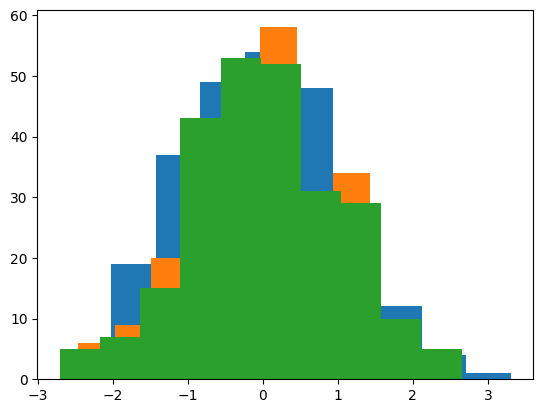

In [4]:
import matplotlib.pyplot as plt
plt.hist(X_tilde_G)
plt.hist(X_tilde_R)
plt.hist(X_tilde_D)



### Exponential strategy

Check under the alternative and then under the null

Final wealth vector: [1.25075474e+00 1.11544840e+05 3.52728164e+07 1.51348946e+08]
Mean wealth: [1.11700023e+00 1.32210807e+04 3.31283421e+06 1.71635043e+07]


(array([ 3., 17., 14.,  5.,  4.,  2.,  1.,  1.,  0.,  2.]),
 array([0.12870669, 0.67716021, 1.22561372, 1.77406724, 2.32252075,
        2.87097426, 3.41942778, 3.96788129, 4.51633481, 5.06478832,
        5.61324183]),
 <BarContainer object of 10 artists>)

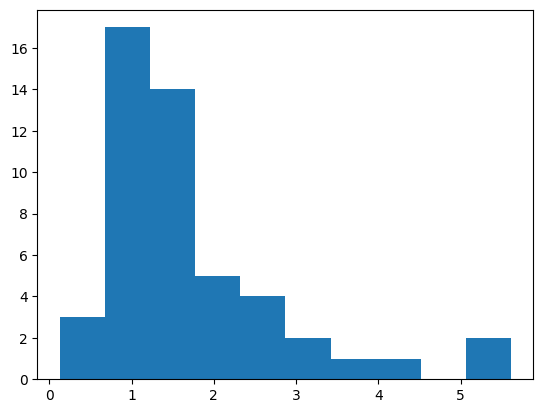

In [6]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from ExponentialBet import ExponentialBet  # adjust import
from utils import prepare_exponential_parameters

etas = prepare_exponential_parameters(0.01, 2, 4)
strategy = ExponentialBet(
    parameters=etas,
    exact=True
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_exp = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_exp = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )
    e_val_path_exp.append(e_val_exp)
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_exp)

### Coin-betting



Final wealth vector: [1.26627058e+00 1.23818746e+00 1.18576693e+00 1.14173449e+00
 1.11054469e+00 1.08911363e+00 1.07414367e+00 1.06332209e+00
 1.05521910e+00 1.04895429e+00 1.49045060e+01 1.16633045e+01
 7.21014697e+00 4.70382642e+00 3.42609035e+00 2.73589976e+00
 2.32946543e+00 2.06975263e+00 1.89231879e+00 1.76445222e+00
 1.40689987e+02 9.15900837e+01 3.89404052e+01 1.80184620e+01
 1.00884349e+01 6.66017160e+00 4.94031593e+00 3.96249904e+00
 3.35037244e+00 2.93800141e+00 1.08870013e+03 6.09453692e+02
 1.88565363e+02 6.45332719e+01 2.84438069e+01 1.57408217e+01
 1.02576597e+01 7.46681951e+00 5.85944996e+00 4.84438119e+00
 7.00624533e+03 3.47145813e+03 8.23983255e+02 2.17058645e+02
 7.69933503e+01 3.61761640e+01 2.08724919e+01 1.38581922e+01
 1.01271063e+01 7.91248216e+00 3.77482745e+04 1.69840785e+04
 3.25979790e+03 6.87991062e+02 2.00537571e+02 8.09612590e+01
 4.16603217e+01 2.53479936e+01 1.73046153e+01 1.28058557e+01
 1.69744344e+05 7.09255956e+04 1.16673682e+04 2.05994725e+03
 5.

(array([ 1.,  0.,  1.,  1.,  5.,  6., 10., 11.,  4., 10.]),
 array([0.08 , 0.268, 0.456, 0.644, 0.832, 1.02 , 1.208, 1.396, 1.584,
        1.772, 1.96 ]),
 <BarContainer object of 10 artists>)

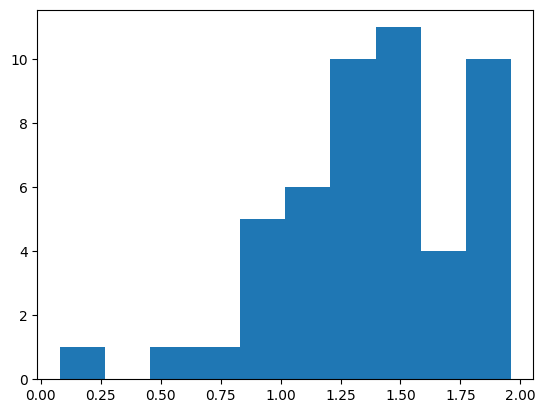

In [7]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_coin_betting_parameters, g_family_cb, update_g_func_static


params = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 1, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_cb = []
for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_cb = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )
    e_val_path_cb.append(e_val_cb)
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_cb)

In [8]:
wealth_path.shape

(49, 100)

In [9]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_coin_betting_parameters, g_family_cb, update_g_func_static


params = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 1, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    e_val_path.append(e_val)
    
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))

Final wealth vector: [1.27696133e+00 1.24110429e+00 1.18527947e+00 1.13899091e+00
 1.10773940e+00 1.08675850e+00 1.07230538e+00 1.06189689e+00
 1.05403389e+00 1.04790805e+00 1.62698328e+01 1.19273454e+01
 7.15739086e+00 4.56767590e+00 3.32386329e+00 2.66597831e+00
 2.28212325e+00 2.03664009e+00 1.86689252e+00 1.74339068e+00
 1.62738847e+02 9.46735775e+01 3.82441653e+01 1.70182854e+01
 9.52043803e+00 6.33874823e+00 4.74985872e+00 3.84166075e+00
 3.26437393e+00 2.87097737e+00 1.31019391e+03 6.31964168e+02
 1.82697527e+02 5.92500808e+01 2.61131047e+01 1.46341556e+01
 9.67906679e+00 7.13211154e+00 5.63789662e+00 4.68150878e+00
 8.62577788e+03 3.58961707e+03 7.86072975e+02 1.93656885e+02
 6.87731628e+01 3.28582309e+01 1.93301723e+01 1.30407800e+01
 9.62218510e+00 7.56151739e+00 4.67443049e+04 1.74423293e+04
 3.05994947e+03 5.96398653e+02 1.74312625e+02 7.18524109e+01
 3.78686145e+01 2.34985216e+01 1.62351412e+01 1.21013703e+01
 2.07287026e+05 7.22748342e+04 1.07898374e+04 1.73535343e+03
 4.

In [10]:
strategy.e_value(model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j)

np.float64(1.84)

(array([ 1.,  0.,  2.,  0.,  5.,  7., 11.,  9.,  5.,  9.]),
 array([0.04 , 0.236, 0.432, 0.628, 0.824, 1.02 , 1.216, 1.412, 1.608,
        1.804, 2.   ]),
 <BarContainer object of 10 artists>)

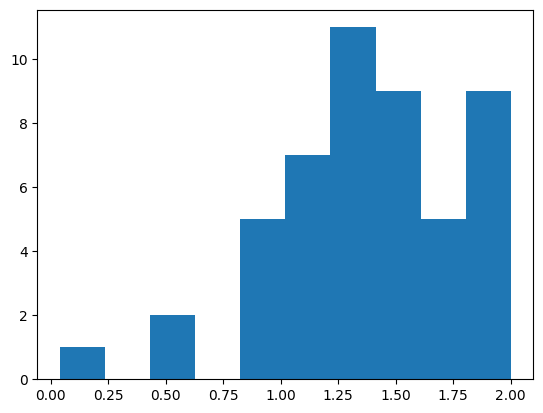

In [11]:
plt.hist(e_val_path)

### Test sign


Prequential false

In [12]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_sign, update_g_func_static

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_sign = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_sign = strategy_sign.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_sign.update()
    e_val_path_sign.append(e_val_sign)
    wealth_path.append(strategy_sign.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))

Final wealth vector: [1.25171774e+00 1.73457684e+02 8.47238767e+03 1.51805488e+05
 3.56022381e+05]
Mean wealth: [1.11780396e+00 3.86844102e+01 1.19522325e+03 1.67143442e+04
 3.40603145e+04]


(array([ 1.,  1.,  3.,  1.,  3.,  3.,  6.,  9.,  8., 14.]),
 array([0.5152 , 0.61418, 0.71316, 0.81214, 0.91112, 1.0101 , 1.10908,
        1.20806, 1.30704, 1.40602, 1.505  ]),
 <BarContainer object of 10 artists>)

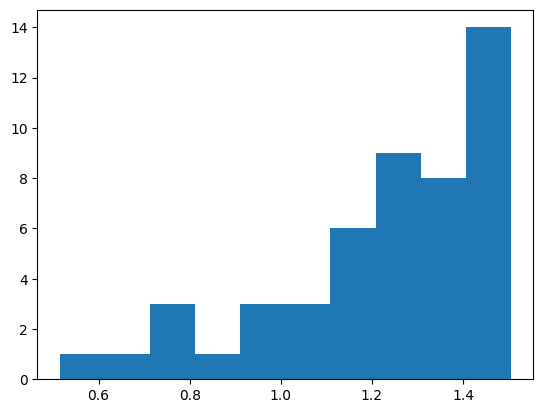

In [13]:
plt.hist(e_val_path_sign)

Prequential true

Final wealth vector: [1.25768959e+00 1.91021491e+02 9.59793612e+03 1.53648216e+05
 0.00000000e+00]
Mean wealth: [1.11706177e+00 3.78310459e+01 1.12736017e+03 1.34607742e+04
 8.93387755e-02]


(array([ 1.,  0.,  0.,  1.,  1., 10.,  7., 12.,  5., 12.]),
 array([0.     , 0.17525, 0.3505 , 0.52575, 0.701  , 0.87625, 1.0515 ,
        1.22675, 1.402  , 1.57725, 1.7525 ]),
 <BarContainer object of 10 artists>)

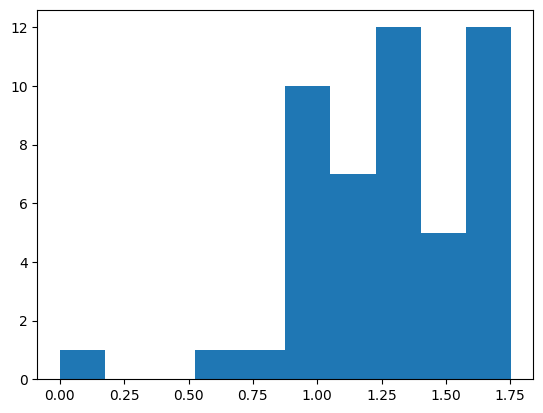

In [14]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_sign, update_g_func_static

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_sign = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_sign = strategy_sign.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_sign.update()
    e_val_path_sign.append(e_val_sign)
    wealth_path.append(strategy_sign.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_sign)

### Tanh

Final wealth vector: [1.26633559e+00 2.27618563e+02 1.38791444e+04 3.03604182e+05
 7.49135667e+05]
Mean wealth: [1.12410971e+00 4.55282934e+01 1.65123536e+03 2.70507234e+04
 5.58610795e+04]


(array([ 1.,  0.,  0.,  1.,  1., 10.,  7., 12.,  5., 12.]),
 array([0.     , 0.17525, 0.3505 , 0.52575, 0.701  , 0.87625, 1.0515 ,
        1.22675, 1.402  , 1.57725, 1.7525 ]),
 <BarContainer object of 10 artists>)

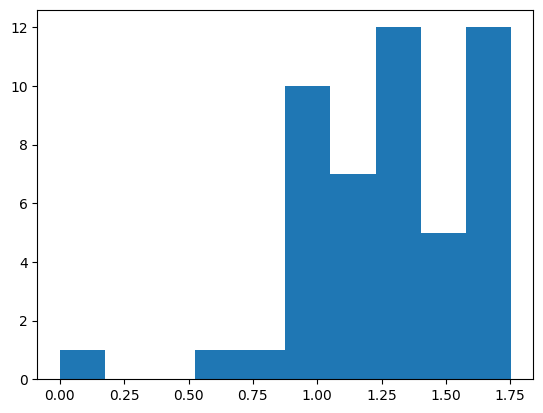

In [15]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_tanh, update_g_func_static

params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_tanh = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_tanh = strategy_tanh.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_tanh.update()
    e_val_path_tanh.append(e_val_tanh)
    wealth_path.append(strategy_tanh.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_sign)

KDE

0
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
Final wealth vector: [1.95116479e+03 1.40145139e+05 2.90953520e+04 3.12034295e+03
 4.02212461e+02 8.45936615e+01 2.80385814e+01 1.29933966e+01
 7.55577322e+00 5.10953498e+00 1.64211672e+00 1.29981390e+05
 1.51641740e+05 5.45272650e+04 2.01829958e+04 4.55598806e+03
 1.04500178e+03 2.40562505e+02 6.50104166e+01 2.15248202e+01
 1.63109370e+00 1.61019145e+05 1.63487118e+05 1.06523603e+05
 5.11069719e+04 2.12535276e+04 7.27212588e+03 2.40032304e+03
 7.90002358e+02 2.81408543e+02 1.87612604e+04 6.01382180e+04
 4.21729270e+03 5.39411433e+02 1.40671755e+02 5.73966324e+01
 3.05982482e+01 1.92660560e+01 1.35296349e+01 1.02409843e+01
 1.75100129e+00 1.60002418e+05 1.65244573e+05 1.16874661e+05
 6.22804904e+04 2.92176866e+04 1.15040419e+04 4.30070326e+03
 1.57759661e+03 6.11553103e+02]
Mean wealth: [2.86633425e+02 1.72392873e+

(array([ 1.,  0.,  1.,  0.,  8.,  7., 10., 10.,  5.,  7.]),
 array([0.15472277, 0.32542875, 0.49613474, 0.66684072, 0.83754671,
        1.00825269, 1.17895868, 1.34966466, 1.52037065, 1.69107663,
        1.86178262]),
 <BarContainer object of 10 artists>)

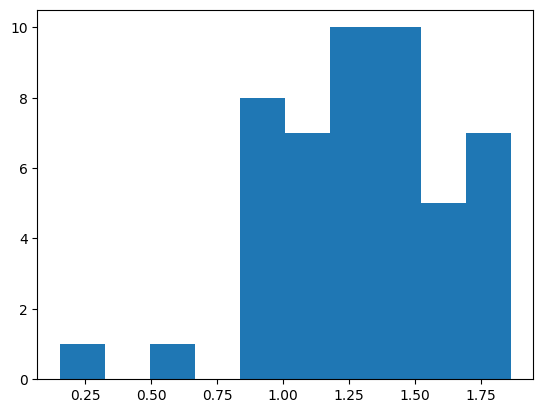

In [ ]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_kernel_density_parameters, g_family_kde, update_g_func_kernel_density, initialize_kde_history
from tqdm.notebook import tqdm
batch = 5

params_kde = prepare_kernel_density_parameters()
model_for_history = LassoCV()
batch_sizes = [batch]
sampdoria = DefaultSampler(j=j)
q, q_tilde = initialize_kde_history(X_train, y_train, [sampdoria], [j], batch_sizes, model = model_for_history)
past_qs = list(zip(q[batch], q_tilde[batch][j]))
strategy_kde = AntisymmetricBet(
    g_family= g_family_kde, 
    update_g_func = update_g_func_kernel_density, 
    parameters=params_kde,
    prequential=True,
    past_qs = past_qs
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_kde = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_kde = strategy_kde.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_kde.update()
    e_val_path_kde.append(e_val_kde)
    wealth_path.append(strategy_kde.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_kde)

(array([ 1.,  0.,  1.,  0.,  8.,  7., 10., 10.,  5.,  7.]),
 array([0.15472277, 0.32542875, 0.49613474, 0.66684072, 0.83754671,
        1.00825269, 1.17895868, 1.34966466, 1.52037065, 1.69107663,
        1.86178262]),
 <BarContainer object of 10 artists>)

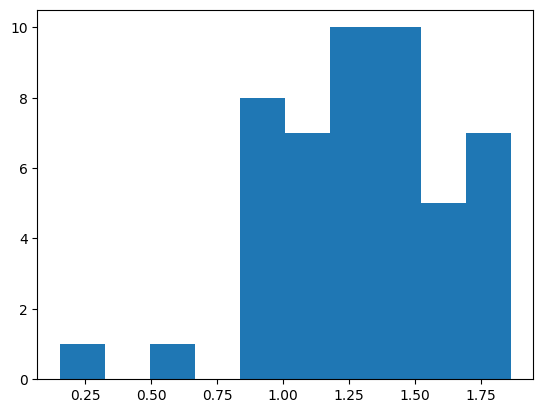

In [17]:
import matplotlib.pyplot as plt
plt.hist(e_val_path_kde)

In [22]:
strategy_kde.past_qs

[(0.5654050460498329,
  array([1.87426334, 0.9324882 , 2.62129309, 1.06126715, 1.55071381,
         1.36108167, 1.84207026, 1.40160163, 1.86440674, 1.06704813])),
 (1.5206826463906244,
  array([2.29416901, 2.20059415, 3.47060042, 2.84605566, 1.80109335,
         2.56760289, 2.93672375, 2.52603659, 2.40802886, 2.14207975])),
 (0.40966839286541923,
  array([0.83669625, 1.12313079, 1.19879828, 2.60802645, 2.62770757,
         1.50957189, 2.01124883, 0.57093352, 1.77214777, 1.73925118])),
 (0.2902443890983302,
  array([0.59517626, 1.01319072, 0.2938034 , 0.25371198, 0.76966067,
         0.8340476 , 0.80741348, 0.23285474, 0.77401872, 0.70589647])),
 (0.6782048725488693,
  array([2.87568005, 1.45852159, 0.9793339 , 3.07251756, 1.94719133,
         1.71513892, 1.69556421, 1.81494601, 1.75765616, 2.46137153])),
 (0.6955186586098769,
  array([1.76624082, 1.41380032, 1.79984122, 1.41351923, 1.08228372,
         1.61406809, 1.29724845, 0.65974985, 1.30222135, 1.24913523])),
 (1.4817626752076738,